# Tecnoteca — Notebook del equipo de Ciencia de Datos

**Hackathon ONE G9 (Alura + Oracle)** · Organización inteligente de contenido técnico

**Objetivo.** Recibir textos técnicos (descripciones de cursos, tutoriales, apuntes, documentación)
y devolver información estructurada en JSON: **categoría** (con probabilidad), **palabras clave**,
**tema** (agrupación no supervisada) y **contenidos relacionados** por similitud.

**Enfoque.**
1. Corpus propio del equipo (requisito del hackathon): generado por plantillas + un conjunto de evaluación escrito a mano.
2. Vectorización **TF-IDF** (1-2 gramas, stopwords en español).
3. Clasificación con **Regresión Logística** (multiclase, 8 categorías).
4. Agrupación por temas con **K-Means** y recomendación por **similitud coseno**.
5. Serialización con **joblib**; el artefacto lo consume el servicio FastAPI y, a través de él, la API pública en Spring Boot.
6. El artefacto puede publicarse en **OCI Object Storage** como registro de modelos (`servicio_modelo/oci_almacen.py`).

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd()
if RAIZ.name == 'ciencia_datos':
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 42
ACENTO = '#5b8def'          # un solo matiz para marcas de una sola serie
TINTA = '#33404f'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c7cdd6', 'axes.labelcolor': TINTA, 'text.color': TINTA,
    'xtick.color': TINTA, 'ytick.color': TINTA, 'axes.grid': True,
    'grid.alpha': 0.25, 'grid.linestyle': '-', 'font.size': 10,
})
print('Raíz del proyecto:', RAIZ)

Matplotlib is building the font cache; this may take a moment.


Raíz del proyecto: /Users/diegoctrfork/Desktop/tmp/tecnoteca


## 1. Datos: construcción del corpus propio

El hackathon pide que **cada equipo construya su propia base de contenidos**. Nuestro corpus tiene dos partes:

- **`data/contenidos.csv`** — 1.200 descripciones de contenido técnico en español (150 por categoría), compuestas
  por `ciencia_datos/generar_dataset.py` a partir de un catálogo de ~100 temas y plantillas de redacción, con semilla fija (reproducible).
- **`data/evaluacion_manual.csv`** — 48 textos **escritos a mano por el equipo**, con redacciones distintas a las plantillas.
  Este conjunto NUNCA se usa para entrenar: mide la generalización real.

Categorías: Backend, Frontend, Ciencia de Datos, DevOps, Bases de Datos, Seguridad, Móvil y Cloud.

In [2]:
if not (RAIZ / 'data' / 'contenidos.csv').exists():
    from ciencia_datos.generar_dataset import main as generar
    generar()

contenidos = pd.read_csv(RAIZ / 'data' / 'contenidos.csv')
manual = pd.read_csv(RAIZ / 'data' / 'evaluacion_manual.csv')
print(f'Corpus generado: {contenidos.shape[0]} filas · Evaluación manual: {manual.shape[0]} filas')
contenidos.sample(5, random_state=SEMILLA)

Corpus generado: 1200 filas · Evaluación manual: 48 filas


,titulo,texto,categoria
1178,CSS moderno: conceptos clave,Guía orientado a equipos técnicos donde aprend...,Frontend
865,Curso de React Native,Resumen de la clase sobre las aplicaciones móv...,Móvil
101,Apuntes de pruebas en móvil,Resumen de la clase sobre las pruebas de aplic...,Móvil
439,Taller práctico: bases de datos gestionadas,Artículo avanzado sobre las bases de datos ges...,Cloud
58,Cómo dominar diseño responsive,En este apunte de estudio se presentan los con...,Frontend


## 2. Análisis exploratorio (EDA)

Antes de modelar: ¿está balanceado el corpus?, ¿cuánto miden los textos?, ¿hay nulos o duplicados?

Nulos por columna:
titulo       0
texto        0
categoria    0

Textos duplicados: 0


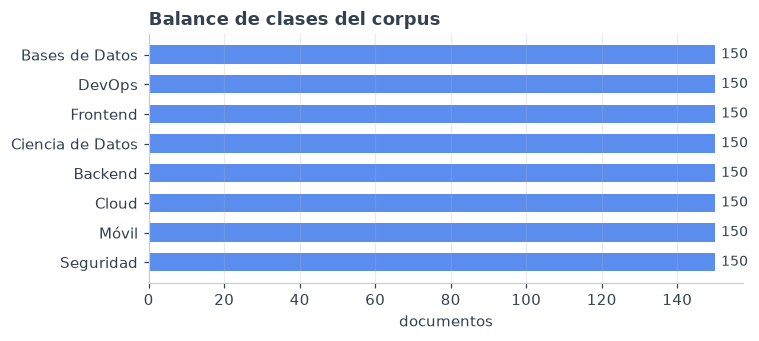

In [3]:
print('Nulos por columna:')
print(contenidos.isna().sum().to_string())
print(f"\nTextos duplicados: {contenidos['texto'].duplicated().sum()}")

conteo = contenidos['categoria'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7, 3.2))
barras = ax.barh(conteo.index, conteo.values, color=ACENTO, height=0.62)
ax.bar_label(barras, padding=4, fontsize=9)
ax.set_xlabel('documentos')
ax.set_title('Balance de clases del corpus', loc='left', fontweight='bold')
ax.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

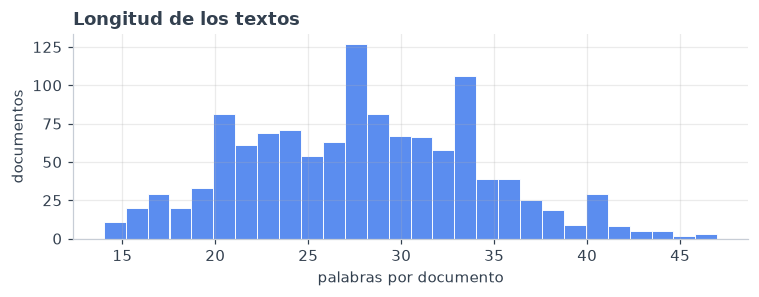

count    1200.0
mean       27.9
std         6.3
min        14.0
25%        23.0
50%        28.0
75%        32.0
max        47.0
Name: texto, dtype: float64

In [4]:
longitudes = contenidos['texto'].str.split().str.len()
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(longitudes, bins=28, color=ACENTO, edgecolor='white', linewidth=0.6)
ax.set_xlabel('palabras por documento'); ax.set_ylabel('documentos')
ax.set_title('Longitud de los textos', loc='left', fontweight='bold')
plt.tight_layout(); plt.show()
longitudes.describe().round(1)

## 3. Limpieza y preparación del texto

- Eliminamos nulos y textos duplicados.
- La **entrada del modelo** es `titulo + '. ' + texto` (el título aporta mucha señal).
- La normalización (minúsculas, sin acentos) la hace el propio vectorizador (`strip_accents='unicode'`),
  por eso nuestras **stopwords están normalizadas igual** (`ciencia_datos/stopwords_es.py`).
- Además de las stopwords clásicas del español, excluimos palabras de *andamiaje educativo*
  ('curso', 'tutorial', 'aprenderás'...) que aparecen por igual en todas las categorías y no aportan señal.

In [5]:
from ciencia_datos.stopwords_es import STOPWORDS_VECTORIZADOR

contenidos = (contenidos.dropna(subset=['titulo', 'texto', 'categoria'])
              .drop_duplicates(subset=['texto']).reset_index(drop=True))
X = contenidos['titulo'].str.strip() + '. ' + contenidos['texto'].str.strip()
y = contenidos['categoria']
print(f'Documentos tras la limpieza: {len(X)}')
print(f'Stopwords totales (español + andamiaje): {len(STOPWORDS_VECTORIZADOR)}')

Documentos tras la limpieza: 1200
Stopwords totales (español + andamiaje): 322


## 4. Vectorización con TF-IDF

TF-IDF pondera cada término por su frecuencia en el documento y lo penaliza si aparece en muchos
documentos: las palabras discriminantes ('kubernetes', 'hibernate') pesan más que las comunes.
Usamos **1-2 gramas** para capturar términos compuestos ('spring boot', 'validación cruzada'),
`min_df=2` para descartar rarezas y `sublinear_tf` para amortiguar repeticiones.

> Estos son los mismos hiperparámetros de `ciencia_datos/entrenar.py`, la versión *script* de este notebook que usa el pipeline productivo.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

def construir_vectorizador():
    return TfidfVectorizer(stop_words=STOPWORDS_VECTORIZADOR, ngram_range=(1, 2),
                           min_df=2, max_features=40000, sublinear_tf=True,
                           strip_accents='unicode', lowercase=True)

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=0.2, stratify=y,
                                              random_state=SEMILLA)
vectorizador = construir_vectorizador()
M_ent = vectorizador.fit_transform(X_ent)
M_pru = vectorizador.transform(X_pru)
densidad = M_ent.nnz / (M_ent.shape[0] * M_ent.shape[1])
print(f'Matriz de entrenamiento: {M_ent.shape[0]} docs × {M_ent.shape[1]} términos '
      f'(densidad {densidad:.4%})')

Matriz de entrenamiento: 960 docs × 2764 términos (densidad 0.7875%)


## 5. Modelo de clasificación: Regresión Logística

Elegimos regresión logística multiclase porque con TF-IDF es un método fuerte para texto corto,
entrega **probabilidades calibradas razonables**, es **explicable** (los coeficientes dicen qué
términos empujan hacia cada categoría) y entrena en segundos, ideal para iterar en un hackathon.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

def construir_clasificador():
    return LogisticRegression(max_iter=2000, C=5.0, class_weight='balanced',
                              random_state=SEMILLA)

clasificador = construir_clasificador().fit(M_ent, y_ent)
y_pred = clasificador.predict(M_pru)
print(f'Exactitud (prueba 20%): {accuracy_score(y_pru, y_pred):.3f}')
print(f'F1 macro (prueba 20%):  {f1_score(y_pru, y_pred, average="macro"):.3f}\n')
print(classification_report(y_pru, y_pred))

Exactitud (prueba 20%): 1.000
F1 macro (prueba 20%):  1.000

                  precision    recall  f1-score   support

         Backend       1.00      1.00      1.00        30
  Bases de Datos       1.00      1.00      1.00        30
Ciencia de Datos       1.00      1.00      1.00        30
           Cloud       1.00      1.00      1.00        30
          DevOps       1.00      1.00      1.00        30
        Frontend       1.00      1.00      1.00        30
           Móvil       1.00      1.00      1.00        30
       Seguridad       1.00      1.00      1.00        30

        accuracy                           1.00       240
       macro avg       1.00      1.00      1.00       240
    weighted avg       1.00      1.00      1.00       240



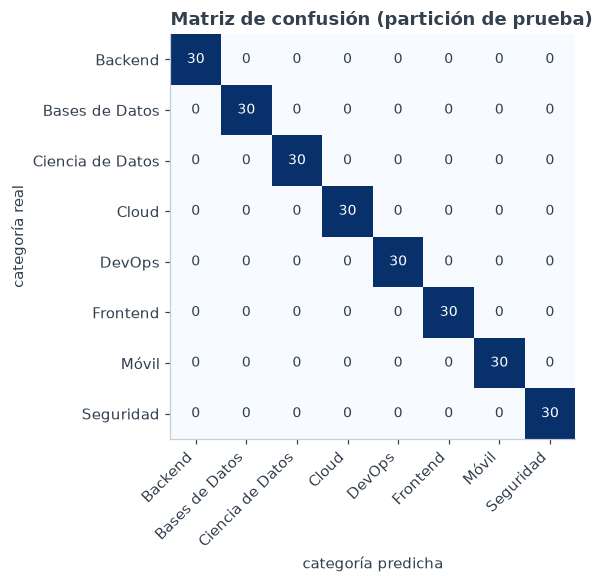

In [8]:
from sklearn.metrics import confusion_matrix

categorias = sorted(y.unique())
cm = confusion_matrix(y_pru, y_pred, labels=categorias)
fig, ax = plt.subplots(figsize=(6.4, 5.4))
imagen = ax.imshow(cm, cmap='Blues')   # secuencial: un matiz, claro → oscuro
ax.set_xticks(range(len(categorias)), categorias, rotation=45, ha='right')
ax.set_yticks(range(len(categorias)), categorias)
ax.set_xlabel('categoría predicha'); ax.set_ylabel('categoría real')
ax.set_title('Matriz de confusión (partición de prueba)', loc='left', fontweight='bold')
ax.grid(False)
umbral = cm.max() / 2
for i in range(len(categorias)):
    for j in range(len(categorias)):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=9,
                color='white' if cm[i, j] > umbral else TINTA)
plt.tight_layout(); plt.show()

In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

cv = cross_val_score(make_pipeline(construir_vectorizador(), construir_clasificador()),
                     X, y, cv=5, scoring='f1_macro')
print(f'Validación cruzada (5 pliegues) F1 macro: {cv.mean():.3f} ± {cv.std():.3f}')
print('Pliegues:', np.round(cv, 4))

Validación cruzada (5 pliegues) F1 macro: 1.000 ± 0.000
Pliegues: [1. 1. 1. 1. 1.]


## 6. Evaluación honesta: el conjunto escrito a mano

Las métricas anteriores rondan el 100% y **hay que desconfiar**: el corpus se generó con plantillas,
así que entrenamiento y prueba comparten estructuras de redacción — el problema resulta *fácil dentro
de la plantilla*. Por eso construimos un conjunto de **48 textos escritos a mano**, con otro estilo,
vocabulario coloquial y varios casos deliberadamente ambiguos. Esta es la métrica que reportamos como
generalización real del modelo.

In [10]:
X_man = manual['titulo'].str.strip() + '. ' + manual['texto'].str.strip()
y_man_pred = clasificador.predict(vectorizador.transform(X_man))
exactitud_manual = accuracy_score(manual['categoria'], y_man_pred)
print(f'Exactitud sobre los 48 textos manuales: {exactitud_manual:.3f}\n')
errores = manual.loc[manual['categoria'] != y_man_pred,
                     ['titulo', 'categoria']].assign(predicha=y_man_pred[manual['categoria'] != y_man_pred])
print('Errores del modelo:' if len(errores) else 'Sin errores.')
errores

Exactitud sobre los 48 textos manuales: 0.979

Errores del modelo:


,titulo,categoria,predicha
1,Manejo global de excepciones en una API,Backend,Frontend


## 7. Palabras clave (`informacion_adicional`)

Estrategia híbrida (`ciencia_datos/tecnologias.py`):
1. **Gazetteer de ~120 tecnologías** con expresiones regulares y nombre canónico
   ('spring boot' → *Spring Boot*, 'k8s' → *Kubernetes*): salida limpia y legible.
2. Si el texto menciona pocas tecnologías, se completa con los **términos de mayor peso TF-IDF** del documento.

In [11]:
from ciencia_datos.tecnologias import palabras_clave

ejemplo = ('Introducción a Spring Boot. En este contenido se presentan los conceptos '
           'básicos para la creación de APIs REST utilizando Java y Spring Boot.')
print('Ejemplo del enunciado →', palabras_clave(ejemplo, vectorizador))
print('Texto sin tecnologías →', palabras_clave(
    'Resumen de la clase sobre el diseño de esquemas y la elección de claves. '
    'Repasamos la normalización y las formas normales con un caso de inventario.',
    vectorizador))

Ejemplo del enunciado → ['Spring Boot', 'API REST', 'Java']
Texto sin tecnologías → ['Normalización', 'esquemas', 'caso inventario', 'eleccion', 'formas']


## 8. Agrupación por temas: K-Means

Complemento **no supervisado**: agrupa los documentos por similitud, sin usar las etiquetas.
Sirve para descubrir la estructura temática del repositorio y etiquetar cada contenido con su *tema*
(los términos dominantes del cluster). Exploramos k con el coeficiente de silueta (distancia coseno).

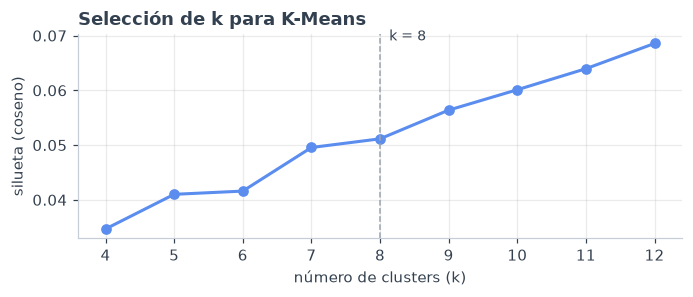

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

M_total = vectorizador.fit_transform(X)   # reajustado con todo el corpus
muestra = np.random.RandomState(SEMILLA).choice(M_total.shape[0], 800, replace=False)
ks = list(range(4, 13))
siluetas = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10).fit(M_total)
    siluetas.append(silhouette_score(M_total[muestra], km.labels_[muestra], metric='cosine'))

fig, ax = plt.subplots(figsize=(6.4, 2.8))
ax.plot(ks, siluetas, color=ACENTO, linewidth=2, marker='o', markersize=6)
k_elegido = 8
ax.axvline(k_elegido, color='#9aa4b0', linewidth=1, linestyle='--')
ax.annotate(f'k = {k_elegido}', (k_elegido, max(siluetas)), textcoords='offset points',
            xytext=(6, 2), fontsize=9)
ax.set_xlabel('número de clusters (k)'); ax.set_ylabel('silueta (coseno)')
ax.set_title('Selección de k para K-Means', loc='left', fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
from ciencia_datos.entrenar import etiquetas_de_clusters

kmeans = KMeans(n_clusters=k_elegido, random_state=SEMILLA, n_init=10).fit(M_total)
temas = etiquetas_de_clusters(vectorizador, kmeans)
pd.DataFrame({'cluster': list(temas), 'términos dominantes': list(temas.values()),
              'documentos': [int((kmeans.labels_ == c).sum()) for c in temas]})

,cluster,términos dominantes,documentos
0,0,"secretos, integracion, continua, gestion",34
1,1,"integrador, aprendido, proyecto, final",150
2,2,"codigo, disponible, repositorio, python",186
3,3,"sql, complementario, practicos, programacion",510
4,4,"autenticacion, multifactor, oauth2, jwt",30
5,5,"oci, oracle, cloud, nube",98
6,6,"preguntas, cierra, seccion, repaso",127
7,7,"apis, rest, api, consumo",65


Los valores de silueta son bajos en términos absolutos — típico en texto corto vectorizado con
TF-IDF (espacio disperso de alta dimensión). Aun así los clusters son interpretables: sus términos
dominantes coinciden en gran medida con las categorías reales, lo que valida la señal temática.

## 9. Similitud y recomendación de contenidos

Con los mismos vectores TF-IDF, la **similitud coseno** entre documentos alimenta dos funciones de la
aplicación: *contenidos relacionados* y *búsqueda semántica*. En producción, el índice vectorial vive
en memoria en el servicio FastAPI (`servicio_modelo/indice.py`) y se sincroniza con la base de datos del back-end Java.

In [14]:
from sklearn.metrics.pairwise import linear_kernel

consulta = 'autenticación con tokens JWT en una API'
similitudes = linear_kernel(vectorizador.transform([consulta]), M_total)[0]
mejores = similitudes.argsort()[::-1][:3]
print(f'Consulta: «{consulta}»\n')
for posicion in mejores:
    print(f'  {similitudes[posicion]:.3f} · [{y.iloc[posicion]}] {contenidos["titulo"].iloc[posicion]}')

Consulta: «autenticación con tokens JWT en una API»

  0.436 · [Backend] Buenas prácticas de autenticación con JWT
  0.434 · [Backend] Guía completa de autenticación con JWT
  0.422 · [Backend] Introducción a autenticación con JWT


## 10. Modelo final y serialización (joblib)

Reentrenamos el clasificador con **todo** el corpus (las métricas ya quedaron estimadas con la
partición de prueba, la validación cruzada y el conjunto manual) y serializamos un único artefacto
con el vectorizador, el clasificador, el K-Means y sus metadatos — el mismo formato que produce
`ciencia_datos/entrenar.py` y que carga el servicio FastAPI.

In [15]:
import joblib, sklearn
from datetime import datetime, timezone

clasificador_final = construir_clasificador().fit(M_total, y)
artefacto = {
    'version': '1.0.0',
    'creado': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'vectorizador': vectorizador,
    'clasificador': clasificador_final,
    'categorias': categorias,
    'kmeans': kmeans,
    'temas_clusters': temas,
    'metricas': {'exactitud_manual': round(float(exactitud_manual), 4),
                 'cv_f1_macro_media': round(float(cv.mean()), 4),
                 'sklearn': sklearn.__version__},
}
(RAIZ / 'models').mkdir(exist_ok=True)
ruta = RAIZ / 'models' / 'modelo.joblib'
joblib.dump(artefacto, ruta, compress=3)
print(f'Artefacto: {ruta} ({ruta.stat().st_size / 1_048_576:.2f} MB)')

# Prueba de humo: recargar y predecir el ejemplo del enunciado
recargado = joblib.load(ruta)
entrada = ('Introducción a Spring Boot. En este contenido se presentan los conceptos '
           'básicos para la creación de APIs REST utilizando Java y Spring Boot.')
vector = recargado['vectorizador'].transform([entrada])
probabilidades = recargado['clasificador'].predict_proba(vector)[0]
ganadora = probabilidades.argmax()
print(f'Predicción tras recargar: {recargado["clasificador"].classes_[ganadora]} '
      f'(probabilidad {probabilidades[ganadora]:.2f})')

Artefacto: /Users/diegoctrfork/Desktop/tmp/tecnoteca/models/modelo.joblib (0.22 MB)
Predicción tras recargar: Backend (probabilidad 0.92)


## 11. Conclusiones y limitaciones

**Resultados.**
- Sobre la partición de prueba y la validación cruzada el modelo es casi perfecto; la métrica honesta
  es la del conjunto manual (~0.98), que usa redacciones ajenas a las plantillas.
- Las palabras clave híbridas (gazetteer + TF-IDF) reproducen la salida esperada del enunciado
  (p. ej. *Java, Spring Boot, API REST*).
- K-Means recupera la estructura temática del corpus y aporta una segunda dimensión de organización.

**Limitaciones conocidas.**
- El corpus generado por plantillas infla las métricas internas; con datos reales esperaríamos cifras menores.
- TF-IDF no captura sinonimia profunda ('contenedores' vs 'Docker' solo se acercan si co-ocurren);
  un siguiente paso natural son los *embeddings* de oraciones para la búsqueda semántica.
- Las 8 categorías son excluyentes; contenidos híbridos (p. ej. *hardening de Linux*) quedan en la frontera
  entre dos clases razonables.

**Próximos pasos.** Ampliar el corpus con datos reales etiquetados desde la propia aplicación
(los contenidos que registran los usuarios), sumar embeddings para la búsqueda y versionar los
artefactos en OCI Object Storage con evaluación automática antes de publicar.